In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN
from bss.ica_utils import fit_icainfomax
from bss.BSSbase import BSSBaseClass

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 100000
NumberofSources = 5
NumberofMixtures = NumberofSources + 5

S = generate_uncorrelated_uniform_sources(NumberofSources, N, min_val = -1, max_val = 1)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  2949187
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.997882340128996


(array([0.33487133, 0.33487461, 0.33477424, 0.33374911, 0.334941  ]),
 array([2.42469274, 1.13460845, 1.9419954 , 1.12889172, 0.645828  ,
        0.90526367, 0.86394017, 1.64557433, 0.54275014, 2.73692455]))

# Hyperparameters

In [3]:
# Compute ICA
Y_ = fit_icainfomax(X, 5)  # Reconstruct signals
# Y_ = (Y_ - Y_.min()) / (Y_.max() - Y_.min())
# Y_ -= Y_.mean(axis = 0, keepdims = True)

Creating RawArray with float64 data, n_channels=10, n_times=100000
    Range : 0 ... 99999 =      0.000 ...    49.999 secs
Ready.
Fitting ICA to data using 10 channels (please be patient, this may take a while)


/nfs/ghome/live/bbozkurt/Desktop/Predictive-Blind-Source-Separation/NotebookExamples/ICA-BSS/../../src/bss/ica_utils.py:38: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(mneobj)


Selecting by number: 5 components
Computing Extended Infomax ICA
Fitting ICA took 4.9s.


In [4]:
Y_ = BSSBaseClass().signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(BSSBaseClass().ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(BSSBaseClass().ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 29.730745595964642
Component Signal-to-Noise-Ratio (SNR) Values : [31.8774035  29.51312283 27.52091046 31.68568733 29.59650051]



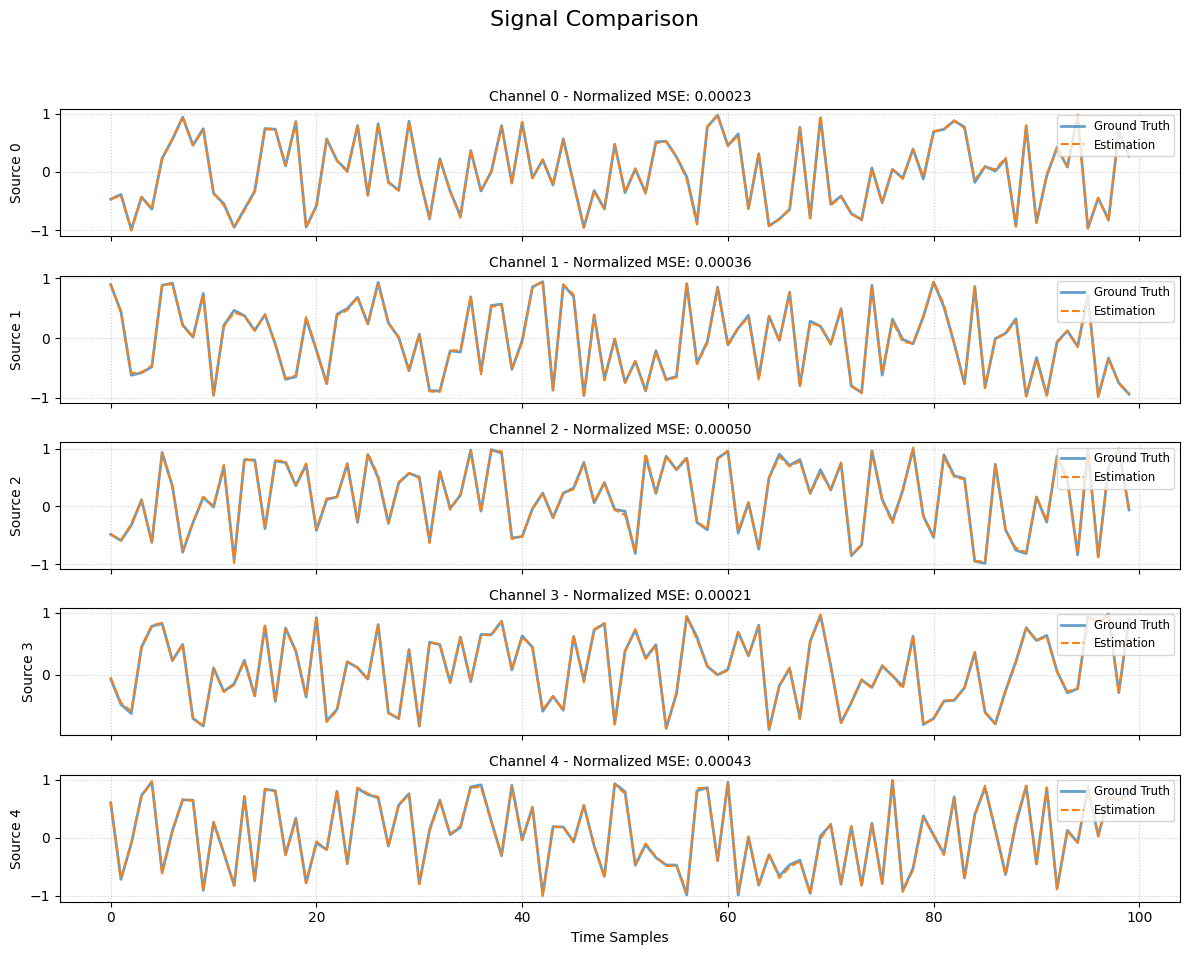

In [5]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])